### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Input data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 30       # number of modelling nodes

In [6]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [7]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
E = 207e9
G = 79.3e9

In [10]:
# integration parameters
tspan = (0., 2)

### Main functions:

In [11]:
Ar=np.pi*(d0/2)**2

In [12]:
def Πe(φ,θ,ψ):
    return np.array([[np.cos(θ),0,np.cos(φ)*np.sin(θ)],
                  [0,1,-np.sin(φ)],
                  [-np.sin(θ),0,np.cos(φ)*np.cos(θ)]])

In [13]:
def Ret_e_t(φ,θ,ψ):
        Cφ=np.array([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.array([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.array([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return Cθ @ Cφ @ Cψ

In [14]:
diag_J_t_rho = 1e2*np.array([1, 1, 2]) # [m^4] 
J_t_rho = np.diag(diag_J_t_rho)

In [15]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [16]:
diag_CR = 1e11*np.array([1, 1, 1]) 
CR=np.diag(diag_CR)

In [17]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [18]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [19]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [20]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [21]:
def ωe(φ,θ,ψ): 
    return Πe(φ,θ,ψ)@theta(φ,θ,ψ)

In [22]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [23]:
def d_s_phi(x,y,z,φ,θ,ψ):
    a1, a2, a3 = ωe(φ,θ,ψ)
    return S(a1, a2, a3 )@phi(x,y,z)

In [24]:
def ne(x, y, z, φ, θ, ψ):
    return (Ret_e_t(φ,θ,ψ)@CT@Ret_e_t(φ,θ,ψ).T@(d_s_phi(x,y,z,φ,θ,ψ).reshape(3,1)
            -Ret_e_t(φ,θ,ψ)@np.array([1,0,0]).reshape(3,1))).reshape(1,3)

In [25]:
def me( φ, θ, ψ):
    return Ret_e_t(φ,θ,ψ)@CR@Ret_e_t(φ,θ,ψ).T@ωe(φ,θ,ψ)

In [26]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):

    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ)*np.sin(θ)],
        [0,              0,  -np.cos(φ)            ],
        [0,              0,  -np.sin(φ)*np.cos(θ)]
    ])
    
    dPi_dtheta = np.array([
        [-np.sin(θ),   0,   np.cos(φ)*np.cos(θ)],
        [0,              0,   0                     ],
        [-np.cos(θ),   0,  -np.cos(φ)*np.sin(θ)]
    ])
    
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ + dPi_dtheta * dθ + dPi_dpsi * dψ

In [27]:
fe_g = np.array([0,0,-mp*9.81])          

In [28]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)

In [29]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

### Static solution

In [30]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [31]:
mi = [mp for i in range(N)]

In [32]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [33]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [34]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [35]:
delta_x=horizontal_length/(N-1)

In [36]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [37]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

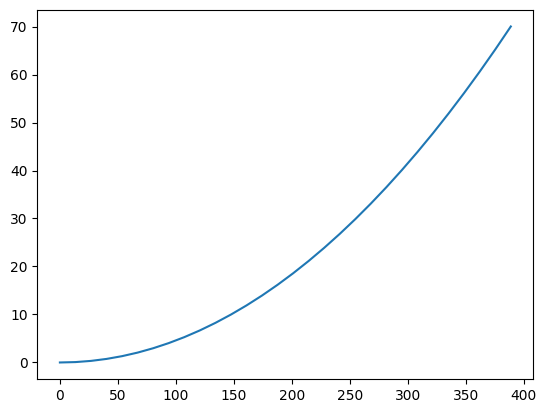

In [38]:
plt.plot(x0, z0)
plt.show()

In [39]:
q0=np.zeros(12*N)

In [40]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [41]:
h = length_p1[-1]/N

In [42]:
def fun1(x_int,φ,θ,ψ):
    A=mp*1/2*(1+x_int)*1/2*(1-x_int)*np.identity(3)
    B=np.zeros((3,3))
    D=1/2*(1+x_int)*1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@Πe(φ,θ,ψ)
    return h/2*np.block([[A, B], [B, D]])

def fun2(x_int,x,y,z,φ,θ,ψ):
    A=1/h*np.identity(3)
    B=np.zeros((3,3))
    C=-1/2*(1+x_int)*S(*d_s_phi(x,y,z,φ,θ,ψ))
    return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x, y, z, φ, θ, ψ)),
                                                          np.asarray(me( φ, θ, ψ))), axis=None)


def fun3(x_int,φ,θ,ψ, dφ, dθ, dψ):
    A=np.zeros(3)
    B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun4(x_int,φ,θ,ψ, dφ, dθ, dψ):
    A=np.zeros(3)   
    B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun5(x_int):
    B=np.zeros(3)   
    A=1/2*(1+x_int)*fe_g
    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun6(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
    B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

def fun7(x_int,x,y,z):
    A=1/2*(1+x_int)*sigma(x,y,z)
    B=np.zeros(3) 

    ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

    return ans

In [43]:
def Assemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]    
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]
    
    return K

In [44]:
def static_solution(Q): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    f2=np.zeros(6*N) 
    f3=np.zeros(6*N) 
    f4=np.zeros(6*N) 
    f5=np.zeros(6*N) 
    f6=np.zeros(6*N) 
#     f7=np.zeros(3*N)
    
    
    K_stat=np.zeros(shape=(6*N,6*N))
    for j in range(1,N):
        block=np.block([[fun1(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1])+fun1(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1]),np.zeros((6,6))],
                       [np.zeros((6,6)), fun1(-1/np.sqrt(3),φ[j],θ[j],ψ[j])+fun1(1/np.sqrt(3),φ[j],θ[j],ψ[j])]])
        K_stat=Assemble(K_stat,block,j-1,j)
        start = 6*(j-1)
        end = start + 6
        f2[start:end] += 2*fun2(0,x[j],y[j],z[j],φ[j],θ[j],ψ[j])
        f3[start:end] += (fun3(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
                            +fun3(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
        f4[start:end] +=  (fun4(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
                            +fun4(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
        f5[start:end] += fun5(-1/np.sqrt(3))+fun5(1/np.sqrt(3))
        f6[start:end] += (fun6(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j])
                            +fun6(1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]))
#         f7[start:end] += fun7(-1/np.sqrt(3),x[j],y[j],z[j])+fun7(1/np.sqrt(3),x[j],y[j],z[j])

    F=f2+f3+f4+f5+f6  
    

    bc=np.array([[0,1,2,3,4,5], 
                 [0,0,0,0,0,0]]).T
    
    nd, nd=K_stat.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    
    K_stat[np.isnan(K_stat)] = 0
    F[np.isnan(F)] = 0
    
    
    s=np.linalg.solve(K_stat[fdof,:][:,fdof] ,
                      (F[fdof].T-np.dot(K_stat[fdof,:][:,pdof],dp.T)).T) 
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    
   
    ddx,ddy,ddz,ddφ,ddθ,ddψ=d.reshape(6,N)
    
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    return ans

In [45]:
# root_ = root(static_solution, q0, method='lm')
# root_ = root(static_solution, q0, method='krylov')
root_ = root(static_solution, q0, method='df-sane')

In [46]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  1.341e+01 ...  0.000e+00  0.000e+00]
     nit: 150
    nfev: 1000
  method: df-sane

In [47]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [48]:
q0 = root_.x                                         # start from static solution

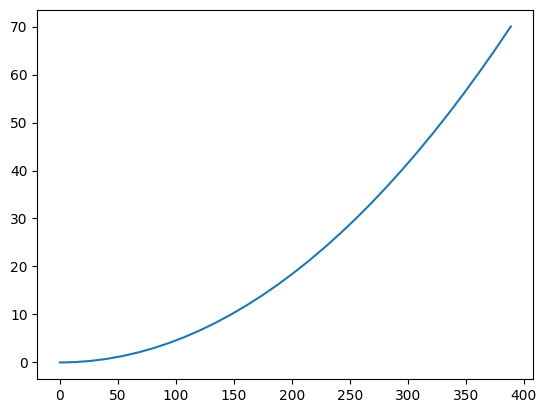

In [49]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [50]:
sampleTime = 0.01              # sample time [seconds]
Number = 6000                      # number of samples

In [51]:
Number*sampleTime

60.0

In [52]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [53]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [54]:
simData.shape 

(6001, 24)

In [55]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

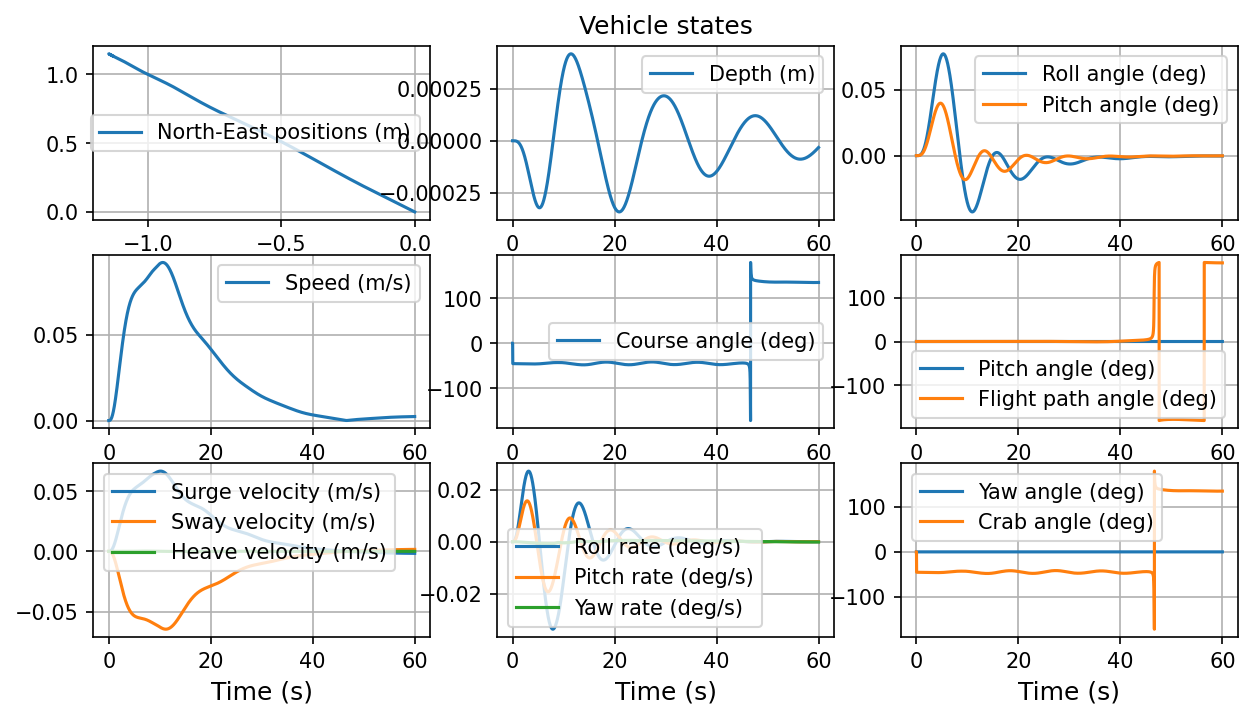

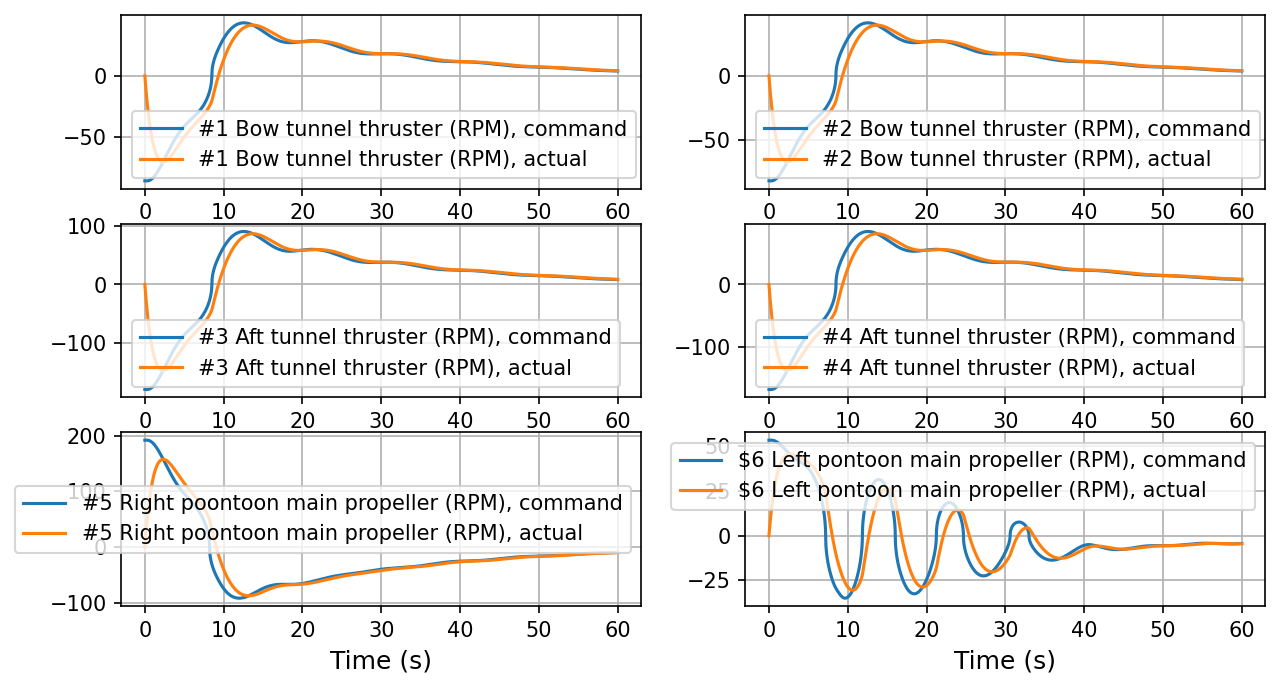

In [56]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [57]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

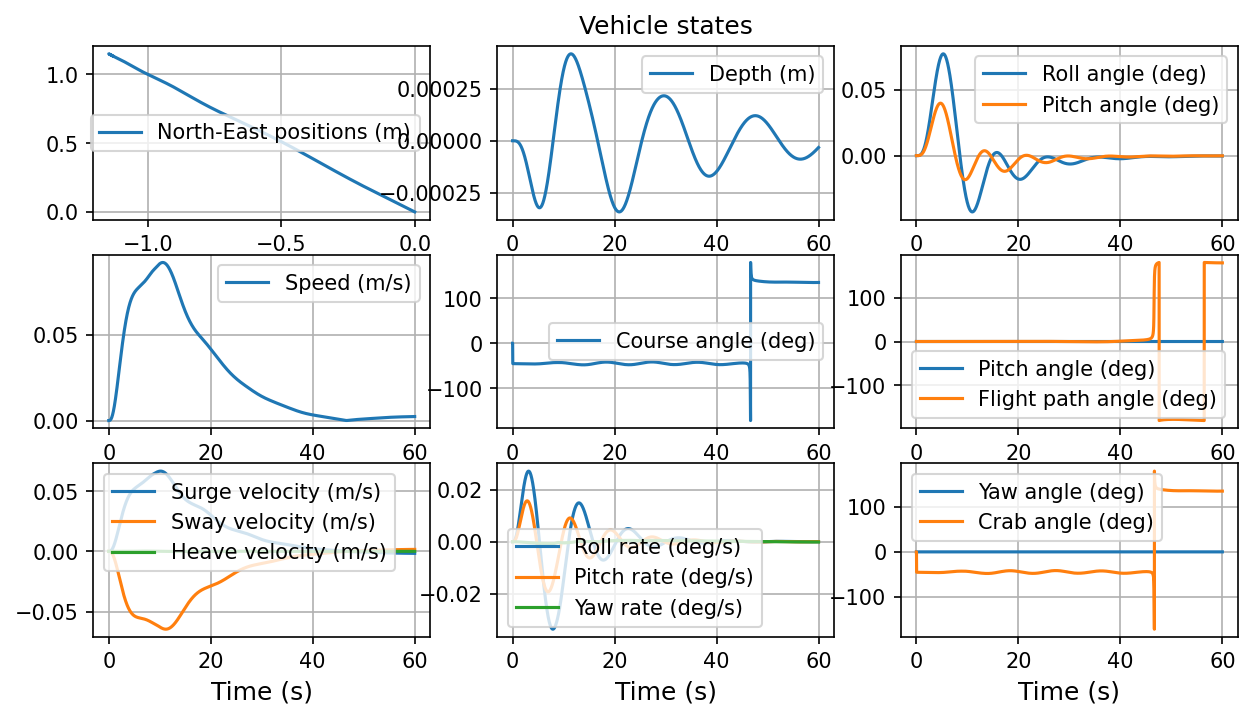

In [58]:
plotVehicleStates(simTime, simData, 3)

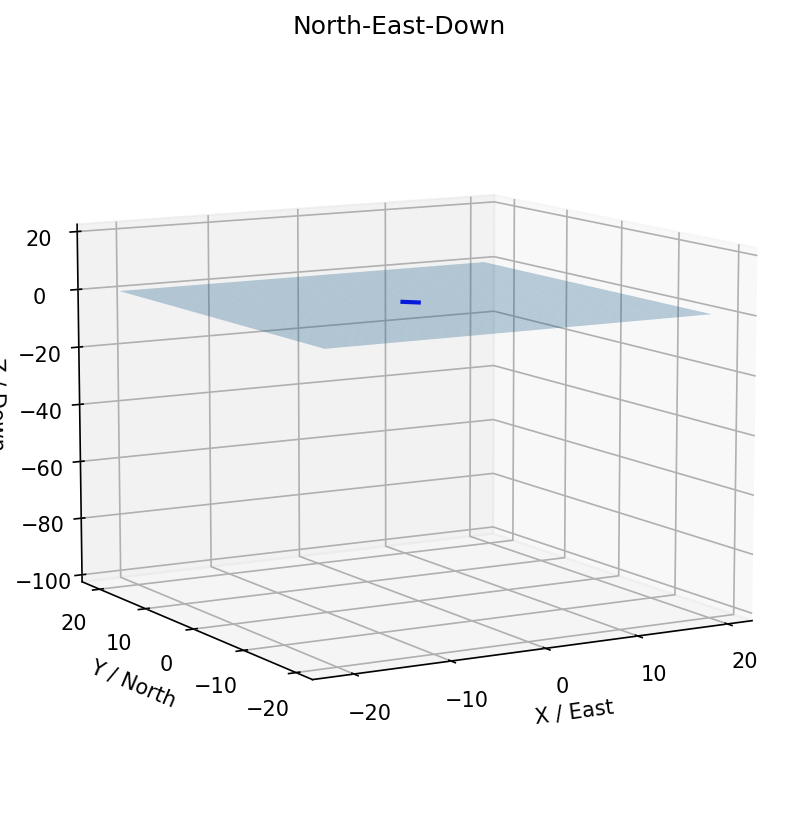

In [59]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [60]:
simData.shape

(6001, 24)

In [61]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [62]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

In [63]:
vessel_motion_func = interp1d(
    ans_t, simData[:, 18:24], axis=0, kind="linear", fill_value="extrapolate"
)

### Dynamic Simulation

In [64]:
def dynamic_func(t, Q, T):
    
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    u_actual = vessel_motion_func(t)
    
    u_actual_x = u_actual[0]
    u_actual_y = u_actual[1]
    u_actual_z = u_actual[2]
    u_actual_phi = u_actual[3]
    u_actual_theta = u_actual[4]
    u_actual_psi = u_actual[5]
        
        
    f2=np.zeros(6*N) 
    f3=np.zeros(6*N) 
    f4=np.zeros(6*N) 
    f5=np.zeros(6*N) 
    f6=np.zeros(6*N) 
    f7=np.zeros(6*N) 
    f8=np.zeros(6*N)
    
    K_stat=np.zeros(shape=(6*N,6*N))
    for j in range(1, N):
        block=np.block([[fun1(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1])+fun1(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1]),np.zeros((6,6))],
                       [np.zeros((6,6)), fun1(-1/np.sqrt(3),φ[j],θ[j],ψ[j])+fun1(1/np.sqrt(3),φ[j],θ[j],ψ[j])]])
        K_stat=Assemble(K_stat,block,j-1,j)
        start = 6*(j-1)
        end = start + 6
        f2[start:end] += 2*fun2(0,x[j],y[j],z[j],φ[j],θ[j],ψ[j])
        f3[start:end] += (fun3(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
                            +fun3(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
        f4[start:end] +=  (fun4(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
                            +fun4(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
        f5[start:end] += fun5(-1/np.sqrt(3))+fun5(1/np.sqrt(3))
        f6[start:end] += (fun6(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j])
                            +fun6(1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]))
#         f7[start:end] += fun7(-1/np.sqrt(3),x[j],y[j],z[j])+fun7(1/np.sqrt(3),x[j],y[j],z[j])
    
    
       
        if t>0.001:
            ax=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j]))@ ne(x[j], y[j], z[j], φ[j], θ[j], ψ[j]).T

            T.top_tension=max(T.top_tension, ax[0][0])            

            ben0=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j])) @ me( φ[j], θ[j], ψ[j]).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)
            
    f8[-6:] += (np.block([[np.identity(3), np.zeros((3,3))], 
                          [np.zeros((3,3)), np.identity(3)]])@u_actual)    
    
    F=f2+f3+f4+f5+f6+f8  
    
    bc=np.array([[0,1,2], 
                 [0,0,0]]).T
    nd, nd=K_stat.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    
    K_stat[np.isnan(K_stat)] = 0
    F[np.isnan(F)] = 0
    
    s=np.linalg.solve(K_stat[fdof,:][:,fdof], 
                      (F[fdof].T-np.dot(K_stat[fdof,:][:,pdof],dp.T)).T)
    
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
     
    ddx,ddy,ddz,ddφ,ddθ,ddψ=d.reshape(6,N)
        
        
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
   
    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()  
        
        
    T.my_iter+=1 
    
    
    return ans

In [65]:
T_ = MyTime()

In [66]:
# initial conditions - to control dynamics
BC=np.zeros(N)
BC[-1]=0.013
q0[8*N:9*N] = BC


# q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
#                                           np.array([0.00003 for i in range(N)]),
#                                           np.array([0.001767*i/N for i in range(N)]))

In [67]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(T_, ), 
             method='RK23'
               )
print(datetime.now() - startTime1)

Physical time:  1.7742817241493996e-12  Iteration wall-clock time:  0:00:00.038950
0:00:09.942857


In [68]:
# 23:33

### Results

In [69]:
T_.my_iter

473

In [70]:
# max axial tension
T_.top_tension

0

In [71]:
# max bending strain
T_.sagbend_strain

0

In [72]:
fin=us_

In [73]:
fin

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  1.774e-10 ...  1.093e-04  1.093e-04]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 1.341e+01  1.341e+01 ...  1.341e+01  1.341e+01]
            ...
            [ 0.000e+00  1.367e-20 ...  5.337e-09  5.337e-09]
            [ 0.000e+00  1.826e-21 ...  9.967e-10  9.967e-10]]
      sol: None
 t_events: None
 y_events: None
     nfev: 473
     njev: 0
      nlu: 0

In [74]:
t=fin.t

In [75]:
fin=fin.y.T

In [76]:
t.shape, fin.shape

((106,), (106, 360))

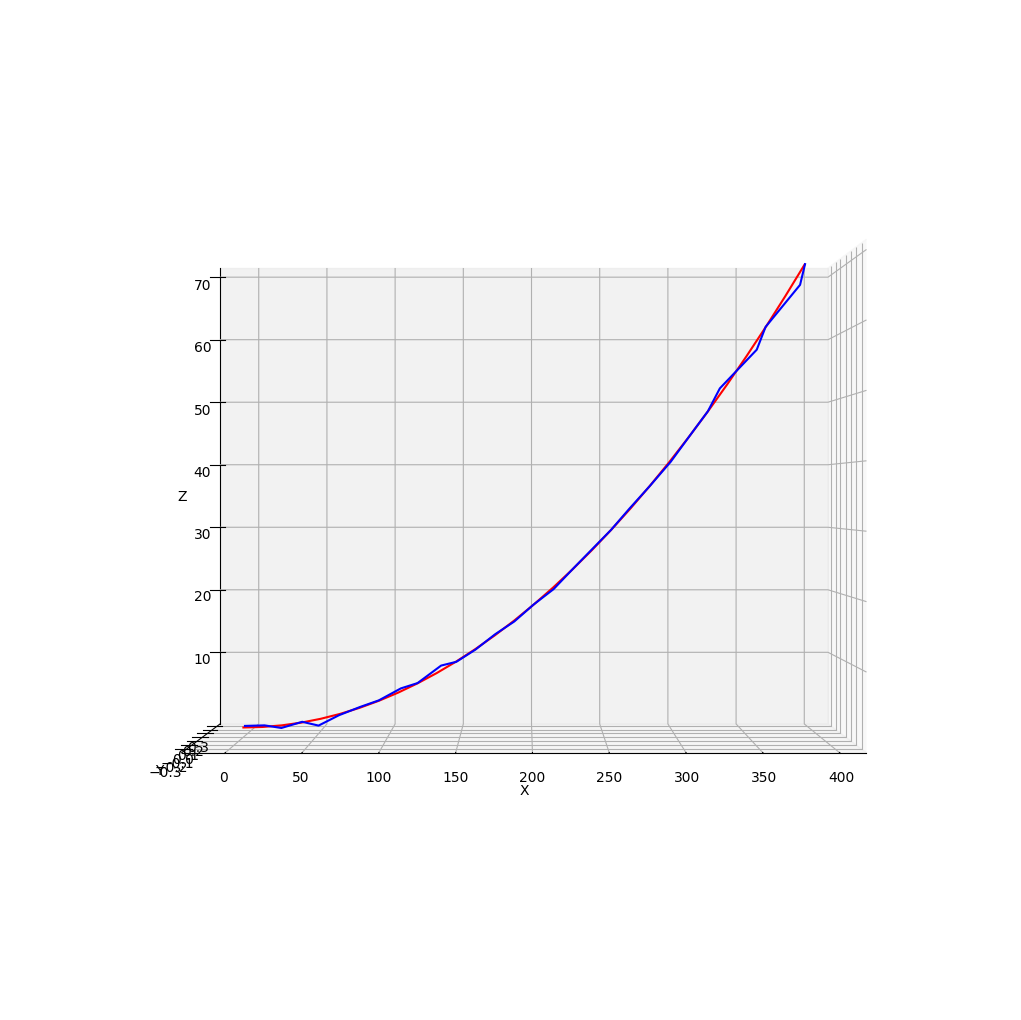

In [77]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [78]:
X,Y,Z

(array([  0.        ,  13.41472778,  26.82945556,  40.2437743 ,
         53.65706707,  67.07345116,  80.51722947,  93.89276343,
        107.13357322, 120.73298789, 134.14801444, 147.56215262,
        161.00411567, 174.39263274, 187.80628975, 201.21879721,
        214.63578092, 228.05027064, 241.51042606, 254.80475182,
        267.3981535 , 281.71004803, 295.12991559, 308.53936963,
        321.98083294, 335.36484917, 348.78376823, 362.1958591 ,
        375.61382894, 389.02669005]),
 array([ 3.48987695e-02,  4.21832369e-02, -1.81659931e-02,  2.11017959e-02,
        -6.86352600e-02, -3.84041961e-02,  1.91327307e-02,  2.06897917e-04,
         1.48956766e-01, -1.43796590e-03,  3.12361430e-01,  6.86164937e-03,
        -3.75986220e-02,  4.97666177e-02, -5.00448958e-02,  7.46245398e-04,
        -1.07076484e-01, -1.94818348e-03,  2.90395173e-02,  3.86864782e-04,
        -2.27999497e-02, -9.93683286e-04, -6.40816241e-02,  6.07569487e-04,
         7.09317449e-04,  2.34549761e-01, -2.71100693e-01,

In [79]:
X0,Y0,Z0

(array([  0.        ,  13.41472778,  26.82945556,  40.24418334,
         53.65891113,  67.07363891,  80.48857744,  93.90309431,
        107.31782225, 120.73255003, 134.14727782, 147.5620056 ,
        160.97694412, 174.39146119, 187.80618894, 201.22091672,
        214.6356445 , 228.05037229, 241.46531081, 254.87982717,
        268.29455564, 281.70928341, 295.12401122, 308.53873897,
        321.9536775 , 335.36819438, 348.78292232, 362.1976501 ,
        375.61237788, 389.02710567]),
 array([-1.65040411e-05, -3.16379148e-04, -3.25780639e-04, -8.79926352e-05,
         7.90979343e-05,  3.97107323e-05,  2.10747003e-04, -3.82286529e-11,
         4.09292283e-07,  3.08148479e-10, -8.36534462e-09,  4.82130487e-11,
         2.10756468e-04,  8.67785133e-10, -8.24684787e-07,  4.94497712e-12,
        -4.66401318e-07, -1.97871232e-11,  2.10746581e-04,  7.37031199e-11,
         3.76429672e-08, -3.93692581e-10,  1.17137230e-08, -9.44689393e-11,
         2.10786606e-04, -2.03711599e-12, -4.10340656e-06,

In [80]:
us=fin.T

In [81]:
us.shape

(360, 106)

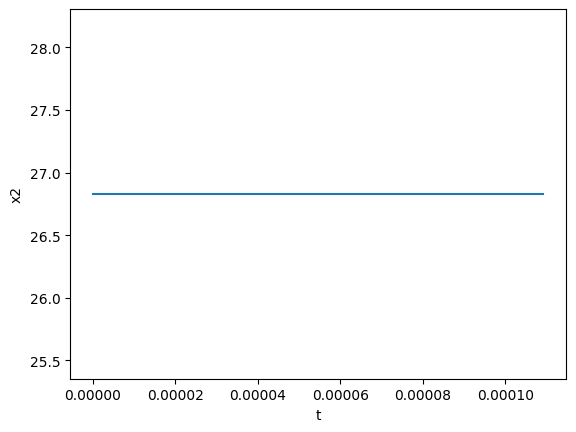

In [82]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

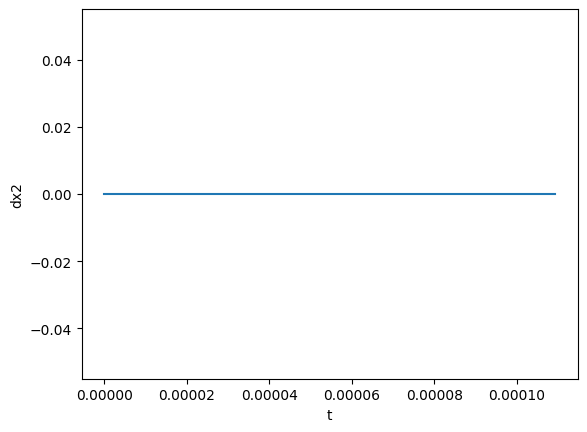

In [83]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

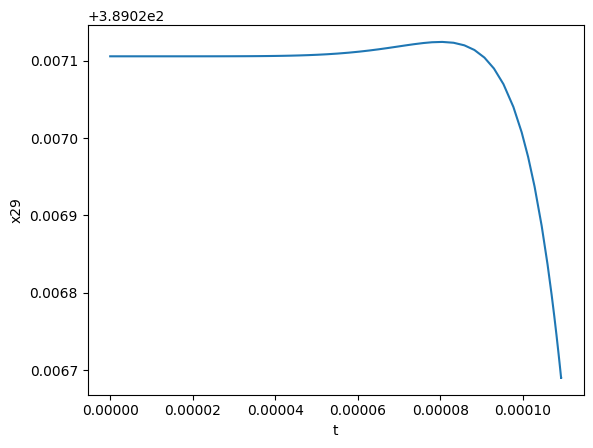

In [84]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

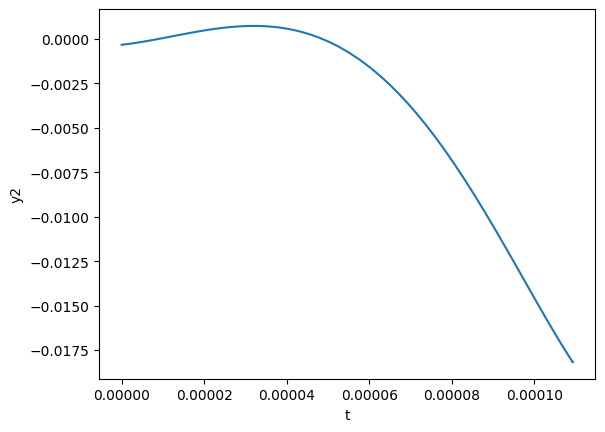

In [85]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

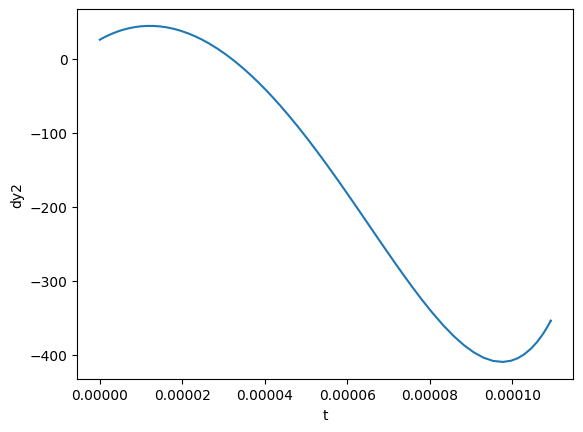

In [86]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

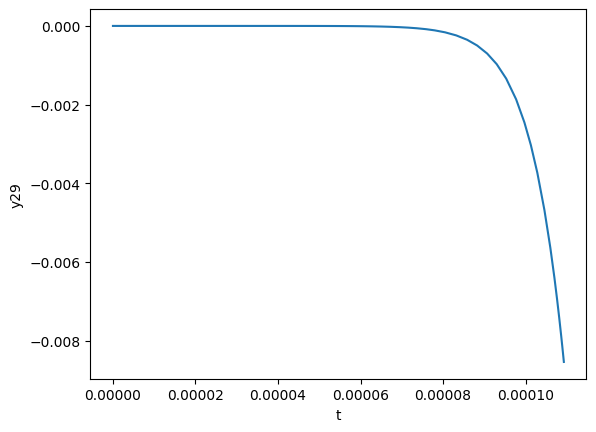

In [87]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

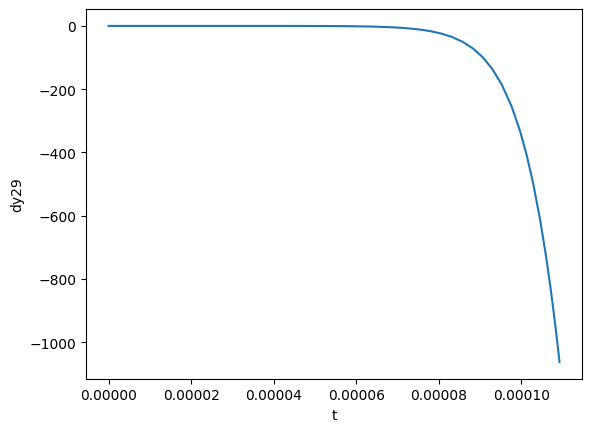

In [88]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

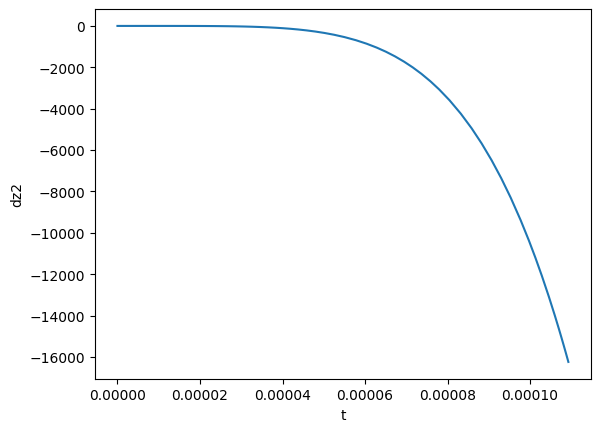

In [89]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

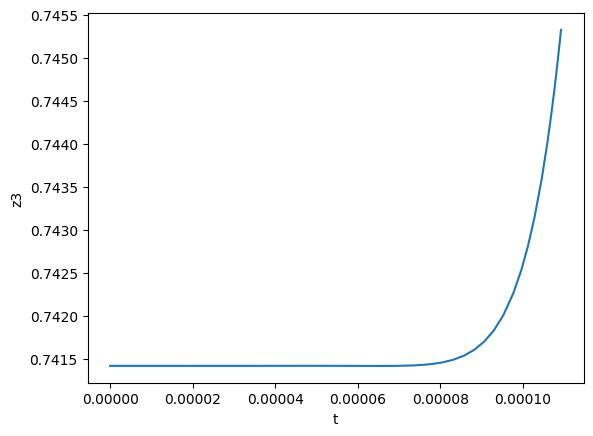

In [90]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

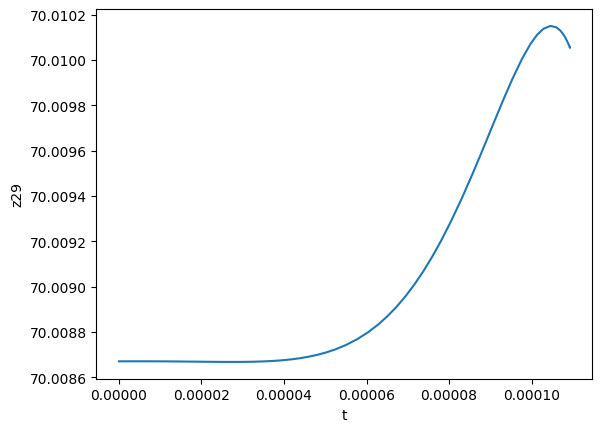

In [91]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

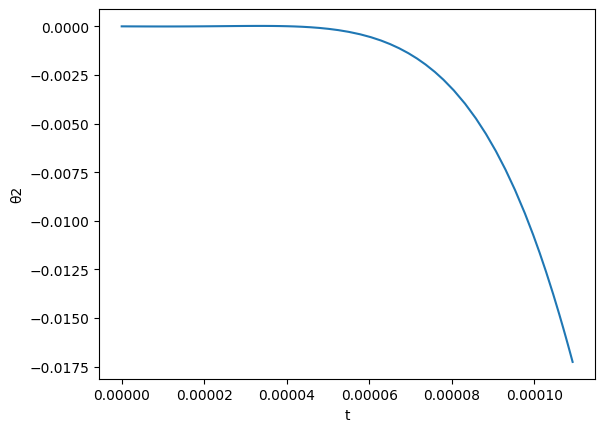

In [92]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

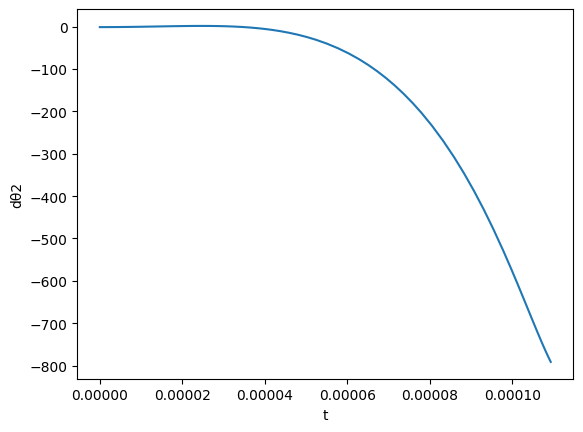

In [93]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

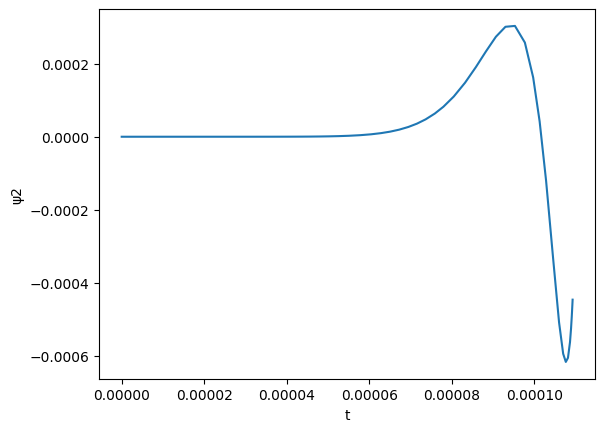

In [94]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

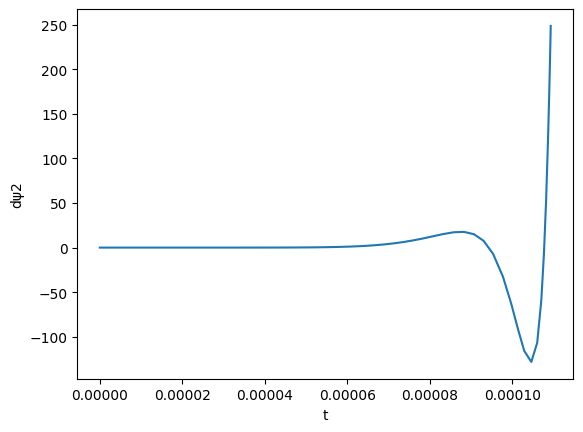

In [95]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

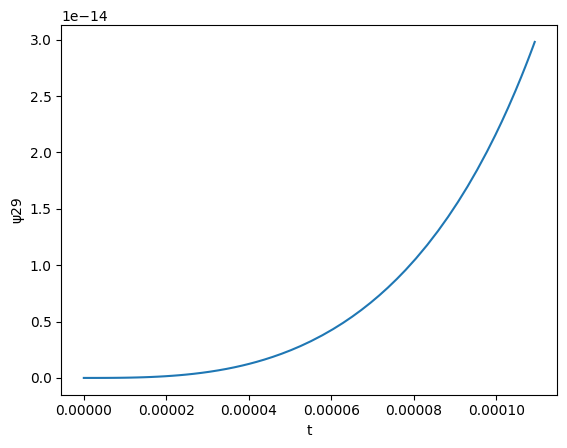

In [96]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [97]:
X010=us.T[:,0*N:1*N]

In [98]:
Y010=us.T[:,2*N:3*N]

In [99]:
Z010=us.T[:,4*N:5*N]

In [100]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()